In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# # just for pipeline
cols_to_keep = [
    'flight_id', 'typecode', 'timestamp', 'fl', 'gs', 'latitude',
    'longitude', 'pressure', 'fuel_flow', 'mass', 'true_airspeed',
    'file', 'altitude_ft', 'waypoint', 'total_fuel_burn'
]

cols_to_keep = [
    'waypoint', 'flight_id', 'typecode', 'timestamp', 'time', 'latitude',
    'longitude', 'fl', 'altitude_ft', 'pressure', 'true_airspeed', #'mach',
    # 'air_temperature', 'specific_humidity', 'u_wind', 'v_wind',
    # 'geopotential', 'potential_vorticity', 'relative_humidity', 'aCCF_O3',
    # 'aCCF_CH4', 'aCCF_NOx', 'aCCF_H2O', 'aCCF_CO2', 
    'aircraft_mass',
    'fuel_flow', #'fuel_burn', 'engine_efficiency', 'altitude', 'level',
    # 'air_pressure', 'segment_length', 'thrust_setting', 'nox_ei',
    # 'nvpm_ei_m', 'nvpm_ei_n', 'co2', 'nox', 'h2o', 'nvpm_mass',
    # 'nvpm_number', 'rh', 'sac', 'ef', 'contrail_age', 'CiC', 'CoCiP', 'O3',
    # 'CH4', 'NOx', 'H2O', 'CO2_with_aCCF', 'CO2', 
    'day', 'fir', 'fl_diff',
    'deviation', 'is_excluded'
]

cols_to_keep = [
    'waypoint', 'flight_id', 'typecode', 'timestamp', 'time', 'latitude',
    'longitude', 'fl', 'altitude_ft', 'pressure', 'true_airspeed', #'mach',
    'aircraft_mass', 'fuel_flow',
    'day', 'fir', 'fl_diff',
    'deviation', 'is_excluded'
]

# to test metrics
cols_to_keep = [
    'waypoint', 'flight_id', 'typecode', 'timestamp', 'time', 'latitude',
    'longitude', 'fl', 'altitude_ft', 'pressure', 'true_airspeed', 'mach',
    'air_temperature', 'specific_humidity', 'u_wind', 'v_wind',
    'geopotential', 'potential_vorticity', 'relative_humidity', 'aCCF_O3',
    'aCCF_CH4', 'aCCF_NOx', 'aCCF_H2O', 'aCCF_CO2', 
    'aircraft_mass',
    'fuel_flow', 'fuel_burn', 'engine_efficiency', 'altitude', 'level',
    'air_pressure', 'segment_length', 'thrust_setting', 'nox_ei',
    'nvpm_ei_m', 'nvpm_ei_n', 'co2', 'nox', 'h2o', 'nvpm_mass',
    'nvpm_number', 'rh', 'sac', 'ef', 'contrail_age', 
    # 'CiC', 'CoCiP', 'O3',
    # 'CH4', 'NOx', 'H2O', 'CO2_with_aCCF', 'CO2', 
    'day', 'fir', 'fl_diff',
    'deviation', 'is_excluded'
]

In [3]:
# # import
# dff = pd.read_parquet("~/Downloads/CONCERTO/2026-05/01_thales_baseline/ex2_org_fps.parquet")
# dfo = pd.read_parquet("~/Downloads/CONCERTO/2026-05/01_thales_baseline/ex2_opt_fps.parquet")
# metaf = pd.read_parquet("~/Downloads/CONCERTO/2026-05/01_thales_baseline/ex2_org_meta.parquet")
# metao = pd.read_parquet("~/Downloads/CONCERTO/2026-05/01_thales_baseline/ex2_opt_meta.parquet")

In [21]:
# import
path_to_data = "~/sourcetree/jecats-paper-data/data/data"
metaf = pd.read_parquet(f"{path_to_data}/filed/filed_meta.parquet")
metao = pd.read_parquet(f"{path_to_data}/optimised/optimised_meta.parquet")
# filter just for pipeline
dff = pd.read_parquet(f"{path_to_data}/filed/filed_trajectories_EAGWP100.parquet")[cols_to_keep]
dfo = pd.read_parquet(f"{path_to_data}/optimised/optimised_trajectories_EAGWP100.parquet")[cols_to_keep]

In [11]:
# df to Flight
from cane.utils import df_to_flight

fleetf = {
    fid: df_to_flight(group)
    for fid, group in dff.groupby("flight_id")
}
fleeto = {
    fid: df_to_flight(group)
    for fid, group in dfo.groupby("flight_id")
}

/Users/jsmretschnig/sourcetree/jecats-paper-climate-mitigation/.venv/lib/python3.11/site-packages/pycontrails/core/vector.py:121: UserWarning: Overwriting data in key `longitude`. Use `.update(longitude=...)` to suppress warning.
  warnings.warn(
/Users/jsmretschnig/sourcetree/jecats-paper-climate-mitigation/.venv/lib/python3.11/site-packages/pycontrails/core/vector.py:121: UserWarning: Overwriting data in key `latitude`. Use `.update(latitude=...)` to suppress warning.
  warnings.warn(
/Users/jsmretschnig/sourcetree/jecats-paper-climate-mitigation/.venv/lib/python3.11/site-packages/pycontrails/core/vector.py:121: UserWarning: Overwriting data in key `time`. Use `.update(time=...)` to suppress warning.
  warnings.warn(
/Users/jsmretschnig/sourcetree/jecats-paper-climate-mitigation/.venv/lib/python3.11/site-packages/pycontrails/core/vector.py:121: UserWarning: Overwriting data in key `altitude_ft`. Use `.update(altitude_ft=...)` to suppress warning.
  warnings.warn(
/Users/jsmretschnig/

In [12]:
# run aircraft performance
from cane.models.aircraft_performance import compute_aircraft_performance

fleetf = {fid: compute_aircraft_performance(flight, None) for fid, flight in fleetf.items()}
fleeto = {fid: compute_aircraft_performance(flight, None) for fid, flight in fleeto.items()}

In [13]:
# update dataframes
dff = pd.concat([f.dataframe for f in list(fleetf.values())], ignore_index=True)
dfo = pd.concat([f.dataframe for f in list(fleeto.values())], ignore_index=True)

In [14]:
# Create folder to save processed files
import os

path_to_processed = os.path.expanduser(f"{path_to_data}/processed")
os.makedirs(path_to_processed, exist_ok=True)

In [15]:
# save to get ready for aCCF intersection and CoCiP on DelftBlue (HPC)
from cane.labels import time_bounds

for i, tb in enumerate(time_bounds):
    day = i + 1
    # dff[dff["timestamp"].between(tb[0], tb[1])].reset_index(drop=True).to_parquet(f"{path_to_data}/processed/filed_trajectories_day{day}.parquet")
    # dfo[dfo["timestamp"].between(tb[0], tb[1])].reset_index(drop=True).to_parquet(f"{path_to_data}/processed/optimised_trajectories_day{day}.parquet")

In [ ]:
# Now it's HPC time!
# download ERA5 data there for the relevant timebounds (either create symbolic link under .cache/pycontrails that points to era5 folder, or pass in era5.py as cache_dir parameter)
# execute run_accfs on HPC
# create day1 ... day8 folders on HPC
# execute run_cocip on HPC

In [16]:
# Import the results
from pathlib import Path

dffs = []
dfos = []
for day in range(8):
    path = Path(f"{path_to_data}/processed/day{day+1}")

    dff = pd.concat(
        (pd.read_parquet(f) for f in path.glob("*filed*.parquet")),
        ignore_index=True
    )
    dffs.append(dff)

    dfo = pd.concat(
        (pd.read_parquet(f) for f in path.glob("*optimised*.parquet")),
        ignore_index=True
    )
    dfos.append(dfo)

dffs = pd.concat(dffs, ignore_index=True)
dfos = pd.concat(dfos, ignore_index=True)

dffs.to_parquet(f"{path_to_data}/processed/filed_trajectories_before_metrics.parquet")
dfos.to_parquet(f"{path_to_data}/processed/optimised_trajectories_before_metrics.parquet")

ValueError: No objects to concatenate

In [22]:
# Assign metrics
from pycontrails import Fleet

# dff = pd.read_parquet(f"{path_to_data}/processed/filed_trajectories_before_metrics.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

# dfo = pd.read_parquet(f"{path_to_data}/processed/optimised_trajectories_before_metrics.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [24]:
# Choose aCCF version
scaling = {
    "vanmanen_2019": {'CiC': 1, 'O3': 1, 'CH4': 1, 'H2O': 1},
    "yin_2023": {"CiC": 1, "O3": 1.97, "CH4": 2.03, "H2O": 1.92},
    "matthes_2023": {"CiC": 3, "O3": 11, "CH4": 35, "H2O": 3},
}
ver = "matthes_2023"

# Select aCCF mask
# [0, 1000] to keep them all and apply filtering while plotting; use [150, 350] for figure D1
accf_bounds = [0, 1000]  # [0, 1000], [150, 350]

# Choose efficacy
efficacy = {
    "dahlmann_2025": {"CiC": 0.21, "O3": 1.05, "CH4": 1.04, "H2O": 1},
    "none": {"CiC": 1, "O3": 1, "CH4": 1, "H2O": 1},
}
eff = "dahlmann_2025"

# Choose target metric
target = "ATR100"  # EAGWP100, ATR100, EAGWP20

In [25]:
from cane.metrics.metrics import compute_metrics_for_fleet

fleetf = compute_metrics_for_fleet(
    fleet=fleetf,
    accf_version=ver,
    accf_scaling=scaling[ver],
    accf_bounds=accf_bounds,
    efficacy=efficacy[eff],
    target=target
)

fleeto = compute_metrics_for_fleet(
    fleet=fleeto,
    accf_version=ver,
    accf_scaling=scaling[ver],
    accf_bounds=accf_bounds,
    efficacy=efficacy[eff],
    target=target
)

Bounds of [0, 1000] in place for aCCF_O3
Bounds of [0, 1000] in place for aCCF_CH4
Bounds of [0, 1000] in place for aCCF_H2O
Bounds of [0, 1000] in place for aCCF_O3
Bounds of [0, 1000] in place for aCCF_CH4
Bounds of [0, 1000] in place for aCCF_H2O


In [10]:
tmp = fleetf.dataframe[["flight_id"] + cols].groupby("flight_id").sum().reset_index()
tmp

,flight_id,CO2,CO2_with_aCCF,CoCiP,CiC,NOx,O3,CH4,H2O
0,0,225633.659204,81184.998457,28150.742877,8.902409e+26,262117.653957,305113.293566,-42995.639609,12580.544180
1,1,275699.601462,99199.170010,130983.877385,4.142242e+27,190958.070561,227468.322086,-36510.251525,22845.149033
2,2,279959.818853,100732.034138,158431.644755,5.010252e+27,249085.924323,300762.794858,-51676.870535,13557.647721
3,3,244397.574702,87936.422230,113979.805373,3.604505e+27,207045.844537,253476.796570,-46430.952033,12828.655752
4,4,346785.512296,124776.513309,-113380.476366,-3.585551e+27,206081.844798,250929.595633,-44847.750835,25132.285743
...,...,...,...,...,...,...,...,...,...
4107,4107,243758.446636,87706.458265,204339.385938,6.462042e+27,176165.246409,218890.078968,-42724.832559,12359.747728
4108,4108,15675.798984,5640.291968,37673.229223,1.191381e+27,26076.958032,28946.241930,-2869.283898,558.809309
4109,4109,28162.708164,10133.193013,124284.691023,3.930387e+27,25621.996660,28604.135860,-2982.139200,1080.805843
4110,4110,17433.238494,6272.634345,213251.964974,6.743894e+27,17835.409720,19807.543025,-1972.133305,977.736876


In [19]:
testf = pd.read_parquet(f"{path_to_data}/filed/filed_trajectories_ATR100.parquet")
test_fleet_f = Fleet(data=testf)

CO2               94.499654
CO2_with_aCCF     40.243888
CoCiP             80.603718
NOx              124.752271
O3               143.088308
CH4              -18.336037
H2O                7.423994
Name: EAGWP100, dtype: float64


<Axes: >

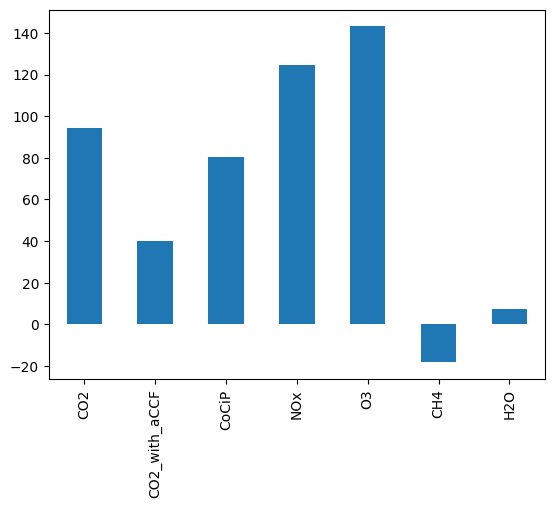

In [20]:
tmp = test_fleet_f.dataframe[["flight_id"] + cols].groupby("flight_id").sum().reset_index()
plotme = tmp[cols].sum().rename(target) / 4112 / 1e3
print(plotme)
plotme.plot.bar()

In [29]:
cols = [
    'CO2', 'CO2_with_aCCF', 'CoCiP',
    'NOx', 'O3', 'CH4', 'H2O',
]

tmp = fleetf.dataframe[["flight_id"] + cols].groupby("flight_id").sum().reset_index()
plotme = tmp[cols].sum().rename(target) / 4112 / 1e3
print(plotme)
# plotme.plot.bar()

CO2               94.499654
CO2_with_aCCF     40.243888
CoCiP             80.603718
NOx              124.752271
O3               143.088308
CH4              -18.336037
H2O                7.423994
Name: ATR100, dtype: float64


In [ ]:
# # (fleet.dataframe.to_parquet(
# #     f"../paper_nox/data_072026_v1bw/df{variant}_{ver}_{eff}_{target}_{accf_bounds}_{calculate_co2eq}.parquet")
# # )
# #%%
# vm = plotme.copy()  # 150-350, no backward calculation
# #%%
# yin = plotme.copy()  # backward calculation
# #%%
# mat = plotme.copy()  # backward calculation
# #%%
# accf_comparison = pd.DataFrame({
#     "van Manen & Grewe (2019)": vm,
#     "Yin et al. (2023) / Dietmüller et al. (2023)": yin,
#     "Matthes et al. (unpublished)": mat
# })
# # accf_comparison = accf_comparison.transpose()[["CO2", "NOx", "O3", "CH4", "H2O"]].transpose()
# #%%
# # filed or optimised? I just checked: it's filed :)
# accf_comparison.to_parquet(
#     f"../paper_nox/data/accf_comparison_{variant}_{ver}_{eff}_{target}_{accf_bounds}_{calculate_co2eq}_fc.parquet")